In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from google.colab.patches import cv2_imshow

# 1. 이미지 로드 (경로를 본인이 올린 파일명으로 수정하세요)
avatar_img = cv2.imread('avatar.png')
original_img = cv2.imread('original.jpeg')

# 두 이미지 크기를 동일하게 맞춰줍니다 (합성을 위해 필수)
h, w, _ = original_img.shape
avatar_img = cv2.resize(avatar_img, (w, h))

# 2. MediaPipe로 메쉬 좌표 추출
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)
results = face_mesh.process(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))

if results.multi_face_landmarks:
    landmarks = results.multi_face_landmarks[0]
    pts = np.array([(int(lm.x * w), int(lm.y * h)) for lm in landmarks.landmark])

    # 입술 안쪽 영역 인덱스
    inner_mouth_idx = [13, 14, 78, 191, 80, 81, 82, 13, 312, 311, 310, 415, 308, 324, 318, 402, 317, 14]
    mouth_pts = pts[inner_mouth_idx]

    # 3. 마스크 생성
    mask = np.ones((h, w), dtype=np.float32)
    cv2.fillPoly(mask, [mouth_pts], 0) # 입술 부분만 구멍(0) 뚫기
    mask = cv2.GaussianBlur(mask, (11, 11), 0) # 경계선 부드럽게

    # 4. 하이브리드 합성 (핵심 로직)
    mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    # 마스크가 1인 곳은 아바타, 0인 곳은 원본(실제 입)이 나옴
    final_result = (avatar_img * mask_3ch) + (original_img * (1 - mask_3ch))

    # 5. 결과 확인
    cv2_imshow(final_result.astype(np.uint8))
else:
    print("얼굴 감지 실패!")

AttributeError: module 'mediapipe' has no attribute 'solutions'

Saving 성현 to 유우시.png to 성현 to 유우시 (1).png
원본 shape: (366, 339, 3)
아바타 shape: (366, 339, 3)


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


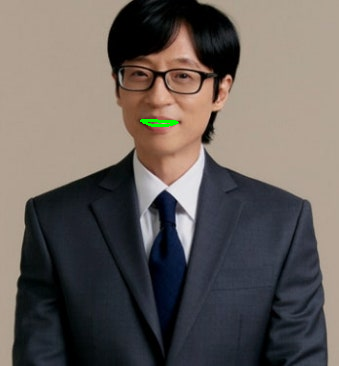

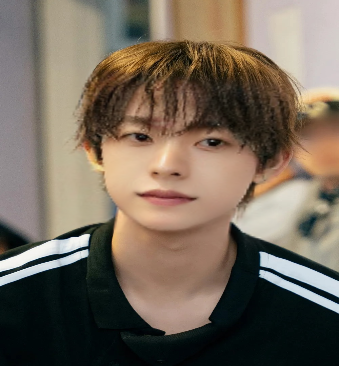

In [ ]:
!pip install mediapipe==0.10.13 opencv-python-headless

import cv2
import mediapipe as mp
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

# 업로드
uploaded = files.upload()

avatar_path = 'avatar.png'
original_path = 'original.jpeg'

# 1) 이미지 로드 체크
avatar_img = cv2.imread(avatar_path, cv2.IMREAD_UNCHANGED)  # 알파 채널까지 읽기
original_img = cv2.imread(original_path)

if avatar_img is None:
    raise ValueError(f"avatar 이미지 로드 실패: {avatar_path}")
if original_img is None:
    raise ValueError(f"original 이미지 로드 실패: {original_path}")

# 2) avatar가 RGBA면 BGR로 변환
if avatar_img.shape[2] == 4:
    alpha = avatar_img[:, :, 3] / 255.0
    avatar_bgr = avatar_img[:, :, :3]
else:
    alpha = None
    avatar_bgr = avatar_img

# 3) 크기 맞추기
h, w = original_img.shape[:2]
avatar_bgr = cv2.resize(avatar_bgr, (w, h))

if alpha is not None:
    alpha = cv2.resize(alpha, (w, h))

# 4) MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
) as face_mesh:

    rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb_img)

if not results.multi_face_landmarks:
    raise ValueError("얼굴 감지 실패! 정면 얼굴, 밝은 사진, 큰 얼굴로 다시 시도해봐.")

landmarks = results.multi_face_landmarks[0]
pts = np.array(
    [(int(lm.x * w), int(lm.y * h)) for lm in landmarks.landmark],
    dtype=np.int32
)

# 5) 입 안쪽 영역
# 너무 복잡하게 쓰기보다 볼록껍질(convex hull)로 안정화
inner_mouth_idx = [78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308, 415]
mouth_pts = pts[inner_mouth_idx]
mouth_hull = cv2.convexHull(mouth_pts)

# 6) 마스크 생성
mask = np.ones((h, w), dtype=np.float32)
cv2.fillConvexPoly(mask, mouth_hull, 0.0)
mask = cv2.GaussianBlur(mask, (21, 21), 0)

mask_3ch = np.dstack([mask, mask, mask])

# 7) 아바타 자체 알파가 있으면 먼저 반영
if alpha is not None:
    alpha_3ch = np.dstack([alpha, alpha, alpha])
    avatar_base = avatar_bgr.astype(np.float32) * alpha_3ch + original_img.astype(np.float32) * (1 - alpha_3ch)
else:
    avatar_base = avatar_bgr.astype(np.float32)

# 8) 최종 합성
final_result = avatar_base * mask_3ch + original_img.astype(np.float32) * (1 - mask_3ch)
final_result = np.clip(final_result, 0, 255).astype(np.uint8)

# 9) 디버그용 시각화
debug = original_img.copy()
cv2.polylines(debug, [mouth_hull], True, (0, 255, 0), 2)

print("원본 shape:", original_img.shape)
print("아바타 shape:", avatar_bgr.shape)

cv2_imshow(debug)
cv2_imshow(final_result)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 114.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


Saving 성현 to 유우시.png to 성현 to 유우시 (2).png
왼쪽: 얼굴 마스크 영역 / 오른쪽: 합성 결과


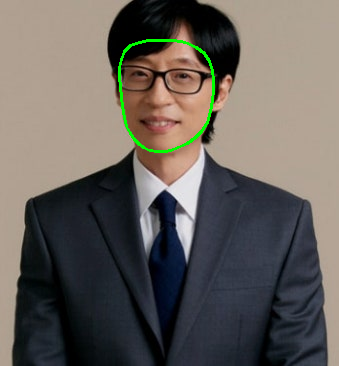

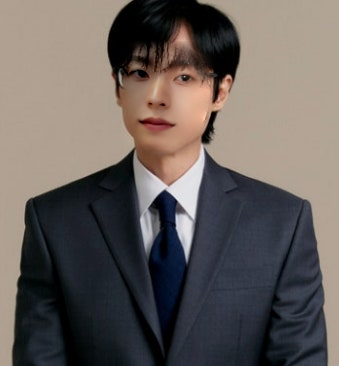

저장 완료: face_swap_result.jpg


In [ ]:
!pip install -q mediapipe==0.10.13 protobuf==3.20.3 numpy==1.23.5 opencv-python-headless

import cv2
import mediapipe as mp
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

# 파일 업로드
uploaded = files.upload()

src_path = "avatar.png"       # 바꿔씌울 아바타 얼굴
dst_path = "original.jpeg"    # 원본 얼굴

src = cv2.imread(src_path)
dst = cv2.imread(dst_path)

if src is None:
    raise ValueError(f"아바타 이미지 로드 실패: {src_path}")
if dst is None:
    raise ValueError(f"원본 이미지 로드 실패: {dst_path}")

mp_face_mesh = mp.solutions.face_mesh

# 얼굴 외곽 중심 인덱스들(전체 얼굴용, 너무 촘촘하지 않게)
FACE_OVAL_IDX = [
    10, 338, 297, 332, 284, 251, 389, 356, 454,
    323, 361, 288, 397, 365, 379, 378, 400, 377,
    152, 148, 176, 149, 150, 136, 172, 58, 132,
    93, 234, 127, 162, 21, 54, 103, 67, 109
]

def get_landmarks(img):
    h, w = img.shape[:2]
    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5
    ) as face_mesh:
        results = face_mesh.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    if not results.multi_face_landmarks:
        return None

    face_landmarks = results.multi_face_landmarks[0]
    pts = np.array(
        [(int(lm.x * w), int(lm.y * h)) for lm in face_landmarks.landmark],
        dtype=np.int32
    )
    return pts

src_pts = get_landmarks(src)
dst_pts = get_landmarks(dst)

if src_pts is None:
    raise ValueError("아바타 이미지에서 얼굴 검출 실패")
if dst_pts is None:
    raise ValueError("원본 이미지에서 얼굴 검출 실패")

# 얼굴 외곽 점
src_face = src_pts[FACE_OVAL_IDX]
dst_face = dst_pts[FACE_OVAL_IDX]

# 아핀 변환보다 전체 얼굴엔 Homography가 덜 안정적일 수 있어서,
# 여기선 삼각분할 없이 간단히 bounding 기준 warp부터 진행
src_rect = cv2.boundingRect(src_face)
dst_rect = cv2.boundingRect(dst_face)

x1, y1, w1, h1 = src_rect
x2, y2, w2, h2 = dst_rect

src_crop = src[y1:y1+h1, x1:x1+w1]

# src 얼굴 점을 crop 좌표계로 이동
src_face_crop = src_face - np.array([x1, y1])
dst_face_rect = dst_face.copy()

# 크기 맞춰서 1차 warp
src_resized = cv2.resize(src_crop, (w2, h2))

# dst 얼굴용 마스크
mask = np.zeros(dst.shape[:2], dtype=np.uint8)
dst_face_shifted = dst_face_rect.copy()
cv2.fillConvexPoly(mask, cv2.convexHull(dst_face_shifted), 255)

# 합성할 중앙점
center = (x2 + w2 // 2, y2 + h2 // 2)

# dst 크기와 같은 빈 캔버스
warped_full = np.zeros_like(dst)
warped_full[y2:y2+h2, x2:x2+w2] = src_resized

# seamless clone
output = cv2.seamlessClone(
    warped_full,
    dst,
    mask,
    center,
    cv2.NORMAL_CLONE
)

# 디버그 시각화
debug = dst.copy()
cv2.polylines(debug, [cv2.convexHull(dst_face)], True, (0, 255, 0), 2)

print("왼쪽: 얼굴 마스크 영역 / 오른쪽: 합성 결과")
cv2_imshow(debug)
cv2_imshow(output)

cv2.imwrite("face_swap_result.jpg", output)
print("저장 완료: face_swap_result.jpg")

Saving 성현 to 유우시.png to 성현 to 유우시 (4).png
원본 얼굴 영역


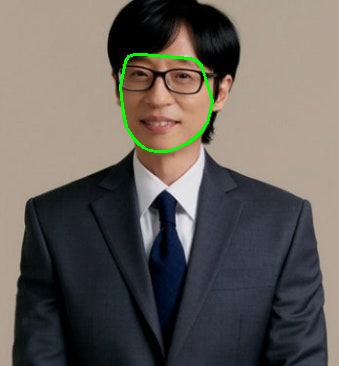

메쉬 기반 아바타 얼굴 치환 결과


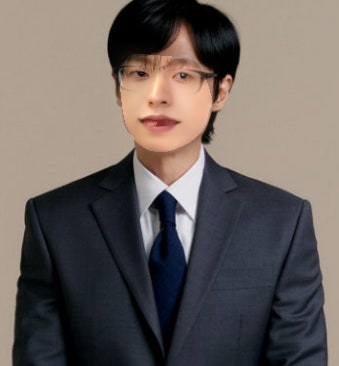

저장 완료: mesh_face_swap_result.jpg


In [ ]:
!pip install -q mediapipe==0.10.13 opencv-python-headless scipy

import cv2
import mediapipe as mp
import numpy as np
from scipy.spatial import Delaunay
from google.colab import files
from google.colab.patches import cv2_imshow

# =========================
# 1. 파일 업로드
# =========================
uploaded = files.upload()

avatar_path = "avatar.png"      # 아바타 얼굴 이미지
original_path = "original.jpeg" # 원본 얼굴 이미지

avatar_img = cv2.imread(avatar_path)
original_img = cv2.imread(original_path)

if avatar_img is None:
    raise ValueError(f"아바타 이미지 로드 실패: {avatar_path}")
if original_img is None:
    raise ValueError(f"원본 이미지 로드 실패: {original_path}")

# =========================
# 2. Face Mesh 추출
# =========================
mp_face_mesh = mp.solutions.face_mesh

def get_landmarks(img):
    h, w = img.shape[:2]
    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5
    ) as face_mesh:
        results = face_mesh.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    if not results.multi_face_landmarks:
        return None

    pts = []
    for lm in results.multi_face_landmarks[0].landmark:
        x = int(lm.x * w)
        y = int(lm.y * h)
        pts.append((x, y))
    return np.array(pts, dtype=np.int32)

avatar_pts = get_landmarks(avatar_img)
original_pts = get_landmarks(original_img)

if avatar_pts is None:
    raise ValueError("아바타 이미지에서 얼굴 검출 실패")
if original_pts is None:
    raise ValueError("원본 이미지에서 얼굴 검출 실패")

# =========================
# 3. 얼굴 영역 인덱스
# =========================
# 얼굴 외곽
FACE_MASK_IDX = [
    70, 63, 105, 66, 107,
    336, 296, 334, 293, 300,
    323, 361, 288, 397, 365, 379, 378, 400, 377,
    152, 148, 176, 149, 150, 136, 172,
    58, 132, 93, 234
]

# 더 자연스럽게 하려면 얼굴 내부 주요 포인트도 포함
USE_IDX = sorted(list(set(
    FACE_MASK_IDX +
    [
        33, 133, 160, 159, 158, 157, 173,     # 왼쪽 눈
        362, 263, 387, 386, 385, 384, 398,    # 오른쪽 눈
        1, 2, 4, 5, 6, 19, 94, 195, 197,      # 코
        61, 146, 91, 181, 84, 17, 314, 405,
        321, 375, 291, 308, 324, 318, 402, 317, 14, 13, 312, 311, 310, 415  # 입
    ]
)))

avatar_face_pts = np.array([avatar_pts[i] for i in USE_IDX], dtype=np.int32)
original_face_pts = np.array([original_pts[i] for i in USE_IDX], dtype=np.int32)

# =========================
# 4. Delaunay 삼각분할
# =========================
# 원본 얼굴 포인트 기준으로 삼각형 생성
tri = Delaunay(original_face_pts)
triangles = tri.simplices

# =========================
# 5. 삼각형 워핑 함수
# =========================
def warp_triangle(src, dst, t_src, t_dst):
    r1 = cv2.boundingRect(np.float32([t_src]))
    r2 = cv2.boundingRect(np.float32([t_dst]))

    x1, y1, w1, h1 = r1
    x2, y2, w2, h2 = r2

    if w1 <= 0 or h1 <= 0 or w2 <= 0 or h2 <= 0:
        return

    t1_rect = []
    t2_rect = []
    t2_rect_int = []

    for i in range(3):
        t1_rect.append((t_src[i][0] - x1, t_src[i][1] - y1))
        t2_rect.append((t_dst[i][0] - x2, t_dst[i][1] - y2))
        t2_rect_int.append((int(t_dst[i][0] - x2), int(t_dst[i][1] - y2)))

    src_rect = src[y1:y1+h1, x1:x1+w1]
    if src_rect.shape[0] == 0 or src_rect.shape[1] == 0:
        return

    mask = np.zeros((h2, w2, 3), dtype=np.float32)
    cv2.fillConvexPoly(mask, np.int32(t2_rect_int), (1.0, 1.0, 1.0), 16, 0)

    mat = cv2.getAffineTransform(np.float32(t1_rect), np.float32(t2_rect))
    warped = cv2.warpAffine(
        src_rect,
        mat,
        (w2, h2),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    warped = warped * mask

    dst_area = dst[y2:y2+h2, x2:x2+w2]
    dst_area = dst_area * (1.0 - mask) + warped
    dst[y2:y2+h2, x2:x2+w2] = dst_area

# =========================
# 6. 삼각형별 워핑
# =========================
warped_face = np.zeros_like(original_img, dtype=np.float32)

for tri_indices in triangles:
    t_src = np.float32([avatar_face_pts[tri_indices[0]],
                        avatar_face_pts[tri_indices[1]],
                        avatar_face_pts[tri_indices[2]]])

    t_dst = np.float32([original_face_pts[tri_indices[0]],
                        original_face_pts[tri_indices[1]],
                        original_face_pts[tri_indices[2]]])

    warp_triangle(avatar_img.astype(np.float32), warped_face, t_src, t_dst)

warped_face = np.clip(warped_face, 0, 255).astype(np.uint8)

# =========================
# 7. 얼굴 마스크 생성
# =========================
mask = np.zeros(original_img.shape[:2], dtype=np.uint8)

mask_pts = np.array([original_pts[i] for i in FACE_MASK_IDX], dtype=np.int32)
hull = cv2.convexHull(mask_pts)

cv2.fillConvexPoly(mask, hull, 255)
mask = cv2.GaussianBlur(mask, (31, 31), 12)

# =========================
# 8. seamlessClone로 자연스럽게 합성
# =========================
x, y, w, h = cv2.boundingRect(hull)
center = (x + w // 2, y + h // 2)

result = cv2.seamlessClone(
    warped_face,
    original_img,
    mask,
    center,
    cv2.NORMAL_CLONE
)

# =========================
# 9. 결과 출력
# =========================
debug = original_img.copy()
cv2.polylines(debug, [hull], True, (0, 255, 0), 2)

print("원본 얼굴 영역")
cv2_imshow(debug)

print("메쉬 기반 아바타 얼굴 치환 결과")
cv2_imshow(result)

cv2.imwrite("mesh_face_swap_result.jpg", result)
print("저장 완료: mesh_face_swap_result.jpg")

In [ ]:
import mediapipe as mp

try:
    _ = mp.solutions.face_mesh
    print("MediaPipe's solutions.face_mesh is accessible. Installation seems correct.")
except AttributeError:
    print("MediaPipe's solutions.face_mesh is NOT accessible. There might be an issue with the installation or environment loading.\nConsider restarting the runtime (`Runtime > Restart runtime` from the menu) and re-running the installation cell.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")